In [1]:
import numpy as np
import pandas as pd 
import plotly.express as px
import plotly.graph_objects as go   
import plotly.figure_factory as ff
import plotly.subplots as sp
import matplotlib.pyplot as plt
import seaborn as sns
import math
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import ccf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None) 

In [2]:
DIR1 = r"../data/train/"

In [3]:
new_trans = pd.read_csv(DIR1 + "new_house_transactions.csv")
pre_trans = pd.read_csv(DIR1 + "pre_owned_house_transactions.csv")
n_pre_trans = pd.read_csv(DIR1 + "pre_owned_house_transactions_nearby_sectors.csv")
n_new_trans = pd.read_csv(DIR1 + "new_house_transactions_nearby_sectors.csv")
land_trans = pd.read_csv(DIR1 + "land_transactions.csv")
city_search = pd.read_csv(DIR1 + "city_search_index.csv")
city_index = pd.read_csv(DIR1 + "city_indexes.csv")
poi = pd.read_csv(DIR1 + "sector_POI.csv")

### Target Analysis 

In [4]:
new_trans.head()

,month,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through
0,2019-Jan,sector 1,52,4906,28184,13827.14,94,265.91,159.0,15904.0,3.78
1,2019-Jan,sector 2,145,15933,17747,28277.73,110,195.02,1491.0,175113.0,12.29
2,2019-Jan,sector 4,6,725,28004,1424.21,127,356.05,40.0,6826.0,5.95
3,2019-Jan,sector 5,2,212,37432,792.10,106,396.05,161.0,17173.0,83.95
4,2019-Jan,sector 6,5,773,15992,607.94,95,151.99,189.0,19696.0,14.27


In [5]:
new_trans['sector'] = new_trans['sector'].str.split(" ").str[1].astype(int)

In [6]:
new_trans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5433 entries, 0 to 5432
Data columns (total 11 columns):
 #   Column                                       Non-Null Count  Dtype  
---  ------                                       --------------  -----  
 0   month                                        5433 non-null   object 
 1   sector                                       5433 non-null   int64  
 2   num_new_house_transactions                   5433 non-null   int64  
 3   area_new_house_transactions                  5433 non-null   int64  
 4   price_new_house_transactions                 5433 non-null   int64  
 5   amount_new_house_transactions                5433 non-null   float64
 6   area_per_unit_new_house_transactions         5433 non-null   int64  
 7   total_price_per_unit_new_house_transactions  5433 non-null   float64
 8   num_new_house_available_for_sale             5419 non-null   float64
 9   area_new_house_available_for_sale            5419 non-null   float64
 10  

In [7]:
new_trans.describe()

,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through
count,5433.000000,5433.000000,5433.000000,5433.000000,5433.000000,5433.000000,5433.000000,5419.000000,5.419000e+03,5419.000000
mean,47.106755,89.184428,9648.461992,43986.200810,32587.559558,128.622492,618.834116,1097.377191,1.271213e+05,21.765900
std,27.291909,161.724622,16691.548417,26488.972347,49047.627905,60.371473,628.762978,1589.671071,1.681336e+05,24.591511
min,1.000000,1.000000,24.000000,5114.000000,50.950000,24.000000,50.950000,1.000000,9.400000e+01,0.020000
25%,23.000000,10.000000,1286.000000,22974.000000,5200.170000,100.000000,247.590000,179.000000,2.389400e+04,7.795000
50%,47.000000,34.000000,4135.000000,39166.000000,16040.320000,112.000000,427.180000,558.000000,7.734500e+04,15.210000
75%,70.000000,96.000000,10528.000000,56832.000000,38499.900000,135.000000,710.820000,1450.000000,1.727540e+05,26.615000
max,96.000000,2669.000000,294430.000000,208288.000000,606407.640000,2003.000000,7803.600000,12048.000000,1.220617e+06,274.260000


In [8]:
new_trans.isnull().sum()

month                                           0
sector                                          0
num_new_house_transactions                      0
area_new_house_transactions                     0
price_new_house_transactions                    0
amount_new_house_transactions                   0
area_per_unit_new_house_transactions            0
total_price_per_unit_new_house_transactions     0
num_new_house_available_for_sale               14
area_new_house_available_for_sale              14
period_new_house_sell_through                  14
dtype: int64

In [9]:
cols = new_trans.select_dtypes(['int64', 'float64']).columns.to_list()

# Tạo subplot 4x2
fig = sp.make_subplots(
    rows=5,
    cols=2,
    subplot_titles=cols
)

# Loop từng cột
for i, col in enumerate(cols):

    row = i // 2 + 1
    col_pos = i % 2 + 1

    data = new_trans[col].dropna()

    # Histogram
    hist = go.Histogram(
        x=data,
        nbinsx=50,
        name=col,
        opacity=0.75,
        showlegend=False
    )

    fig.add_trace(hist, row=row, col=col_pos)

# Update layout
fig.update_layout(
    height=1400,
    width=1200,
    title_text="Histogram Distributions",
    template="plotly_white"
)

fig.show()

> Almost distributions are right skew and have long-tailed

- Real estate market highly heterogeneous
- Long-tail transaction behavior
- Suggesting class segmentation
- Supply concentration exists
- Existence of potential outliers/mega projects 
- Like non-linear relationships


In [10]:

cols = new_trans.select_dtypes(['int64', 'float64']).columns.to_list()

# Tạo subplot
fig = sp.make_subplots(
    rows=3,
    cols=4,
    subplot_titles=cols
)

# Loop từng cột
for i, col in enumerate(cols):

    row = i // 4 + 1
    col_pos = i % 4 + 1

    data = new_trans[col].dropna()

    # Boxplot
    box = go.Box(
        y=data,
        name=col,
        boxmean=True,      # hiện mean
        showlegend=False
    )

    fig.add_trace(box, row=row, col=col_pos)

# Layout
fig.update_layout(
    height=1600,
    width=1200,
    title_text="Boxplot Distributions",
    template="plotly_white"
)

fig.show()

> Data need transform distribution or use log1p

In [11]:
from plotly.subplots import make_subplots

target = 'amount_new_house_transactions'

df = new_trans.copy()

# datetime
df['month'] = pd.to_datetime(df['month'])

# monthly aggregation
monthly_trend = (
    df.groupby('month')[target]
    .mean()
    .reset_index()
)

# log transform
monthly_trend['log_target'] = np.log1p(monthly_trend[target])

# subplot
fig = make_subplots(
    rows=1,
    cols=2,
    subplot_titles=[
        'Raw Target Trend',
        'Log Transformed Target Trend'
    ]
)

# RAW
fig.add_trace(
    go.Scatter(
        x=monthly_trend['month'],
        y=monthly_trend[target],
        mode='lines+markers',
        name='Raw'
    ),
    row=1,
    col=1
)

# LOG
fig.add_trace(
    go.Scatter(
        x=monthly_trend['month'],
        y=monthly_trend['log_target'],
        mode='lines+markers',
        name='Log'
    ),
    row=1,
    col=2
)

# layout
fig.update_layout(
    title='Monthly Trend Comparison: Raw vs Log Target',
    template='plotly_white',
    height=500,
    width=1200,
    showlegend=False
)

fig.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\4238779386.py:8: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['month'])


> In early 2020 => noticeable structural break can be expansion of COVID around China => lockdown, limitation policy ... 

> Strong market rebound observed during late 2020 and 2021. Signs of market cooling and increased instability appear after 2021.

> Potential seasonal patterns observed, with stronger transaction activity toward late-year periods.

> Log transformation stabilizes variance and reveals underlying trends more clearly (4 clear regimes: 2019, early 2020, 2020-2021, 2022). Volatility appears elevated during post-pandemic recovery periods.

In [12]:
df['month_num'] = df['month'].dt.month

seasonality = (
    df.groupby('month_num')[target]
    .mean()
    .reset_index()
)
seasonality2 = (
    df.groupby('month_num')["num_new_house_transactions"]
    .mean()
    .reset_index()
)
fig = make_subplots(rows=1, cols=2, subplot_titles = ['Seasonality Pattern by value of transactions', 'Seasonality Pattern by the number of transaction'])


fig.add_trace(
    go.Bar(
        x=seasonality['month_num'],
        y=seasonality[target],
        name=f'Average {target}'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Bar(
        x=seasonality2['month_num'],
        y=seasonality2["num_new_house_transactions"],
        name='Average num_new_house_transactions'
    ),
    row=1, col=2
)
fig.update_layout(
    template='plotly_white',
    xaxis_title='Month',
    yaxis_title='Average Target'
)

fig.show()

> Rising the number of transaction at the late of a year

In [13]:
df['year'] = df['month'].dt.year

yearly = (
    df.groupby('year')[target]
    .mean()
    .reset_index()
)

fig = px.line(
    yearly,
    x='year',
    y=np.log1p(yearly[target]),
    markers=True,
    title='Year-over-Year Trend'
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

In [14]:
monthly = (
    df.groupby('month')[target]
    .mean()
    .reset_index()
)

monthly['rolling_3m'] = (
    monthly[target]
    .rolling(3)
    .mean()
)

monthly['rolling_6m'] = (
    monthly[target]
    .rolling(6)
    .mean()
)

fig = px.line(
    monthly,
    x='month',
    y=[target, 'rolling_3m', 'rolling_6m'],
    title='Rolling Trend Analysis'
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

> 2020:
- Early 2020: reach a bottom in both raw series and rollig 3m and 6m => market-wide shock not only random fluctuate
- Late 2020-2021: Strong bull run => rolling 3m rise rapidly, rolling 6m rise but lag, raw spike continuously  => strong momentum => 3m > 6m => trend short_term > trend long_term
- 2022-2024: decline => demand wealening, tightening policy, crisis (3 red lines policy, debt crackdown...) => New regime


In [15]:
target = 'amount_new_house_transactions'

df = new_trans.copy()

# Time format
df['month'] = pd.to_datetime(df['month'])

# Monthly mean
monthly = (
    df.groupby('month')[target]
    .mean()
    .reset_index()
)

# Rolling volatility
monthly['rolling_std_3m'] = (
    monthly[target]
    .rolling(window=3)
    .std()
)

monthly['rolling_std_6m'] = (
    monthly[target]
    .rolling(window=6)
    .std()
)

# Plot
fig = go.Figure()

# Raw volatility 3m
fig.add_trace(
    go.Scatter(
        x=monthly['month'],
        y=monthly['rolling_std_3m'],
        mode='lines+markers',
        name='Rolling STD 3M'
    )
)

# Raw volatility 6m
fig.add_trace(
    go.Scatter(
        x=monthly['month'],
        y=monthly['rolling_std_6m'],
        mode='lines+markers',
        name='Rolling STD 6M'
    )
)

# Layout
fig.update_layout(
    title='Rolling Volatility Analysis',
    xaxis_title='Month',
    yaxis_title='Rolling Standard Deviation',
    template='plotly_white',
    height=600,
    width=1100,
    hovermode='x unified'
)
fig.update_yaxes(type='log')
fig.show()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\3098085442.py:6: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['month'])


In [16]:
target = 'amount_new_house_transactions'
volume_col = 'num_new_house_transactions'

df = new_trans.copy()

# Datetime
df['month'] = pd.to_datetime(df['month'])

# Monthly aggregation
monthly = (
    df.groupby('month')[[target, volume_col]]
    .mean()
    .reset_index()
)

# -----------------------------
# LOG TRANSFORM
# -----------------------------
monthly['log_target'] = np.log1p(monthly[target])
monthly['log_volume'] = np.log1p(monthly[volume_col])

# Rolling volatility trên log target
monthly['rolling_std_6m'] = (
    monthly['log_target']
    .rolling(window=6)
    .std()
)

# Rolling log volume
monthly['rolling_volume_6m'] = (
    monthly['log_volume']
    .rolling(window=6)
    .mean()
)

# -----------------------------
# PLOT
# -----------------------------
from plotly.subplots import make_subplots
import plotly.graph_objects as go

fig = make_subplots(
    rows=1,
    cols=1,
    subplot_titles=[
        'Log Volatility vs Log Transaction Volume Over Time'
    ]
)

# LEFT: Time series
fig.add_trace(
    go.Scatter(
        x=monthly['month'],
        y=monthly['rolling_std_6m'],
        mode='lines+markers',
        name='Rolling Log Volatility (6M)'
    ),
    row=1, col=1
)

fig.add_trace(
    go.Scatter(
        x=monthly['month'],
        y=monthly['rolling_volume_6m'],
        mode='lines+markers',
        name='Rolling Log Volume (6M)',
        yaxis='y2'
    ),
    row=1, col=1
)



# Layout
fig.update_layout(
    template='plotly_white',
    height=600,
    width=1300,
    title='Housing Market: Log Liquidity vs Log Volatility'
)

# Axis labels
fig.update_xaxes(title='Month', row=1, col=1)
fig.update_yaxes(title='Rolling Log Volatility', row=1, col=1)



fig.show()

# Correlation
corr = monthly[['rolling_std_6m', 'rolling_volume_6m']].corr().iloc[0,1]

print(f'Correlation between log volatility and log transaction volume: {corr:.3f}')

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\1199549979.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['month'] = pd.to_datetime(df['month'])


Correlation between log volatility and log transaction volume: -0.376


> Reversed trend: Liquidity increase make volatility decrease

> Existence off volatility clustering 

> volatility spike upward more than downward


In [17]:
monthly['mom_growth'] = (
    monthly[target]
    .pct_change() * 100
)

fig = px.bar(
    monthly,
    x='month',
    y='mom_growth',
    title='Month-over-Month Growth (%)'
)

fig.update_layout(
    template='plotly_white'
)

fig.show()

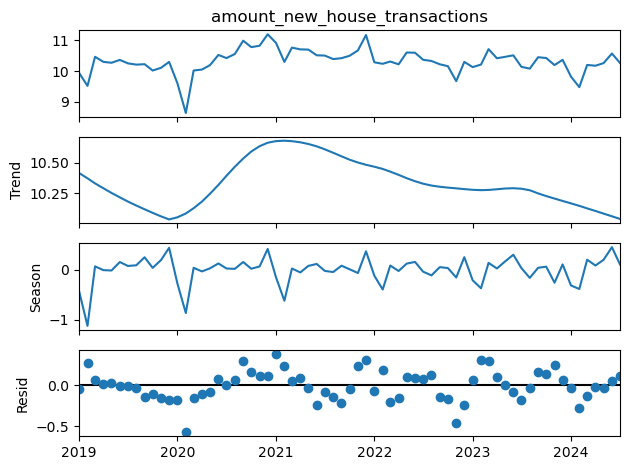

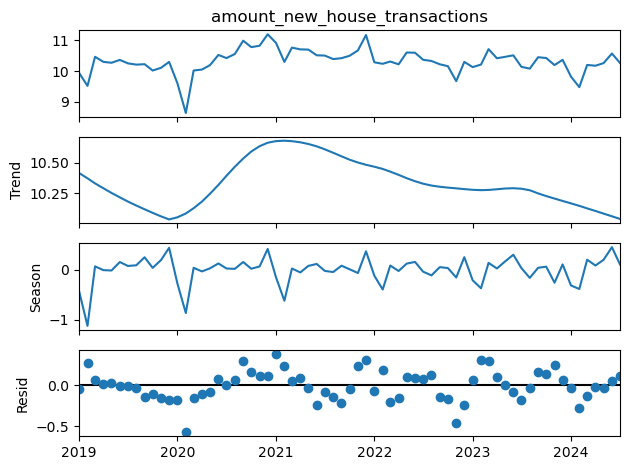

In [18]:
from statsmodels.tsa.seasonal import STL

series = monthly_trend.set_index('month')[target]

stl = STL(np.log1p(series), period=12)
result = stl.fit()

result.plot()

- Cyclical Market: New house transactions are strongly influenced by seasonal factors, particularly a slowdown at the beginning of each year.

- Market Trend: Following a period of strong growth (boom) in 2021, the market for new house transactions has been trending downward (cooling down) during the 2022-2024 period.

- Stability: Despite fluctuations, the volatility remains relatively stable around the average level (approximately 10 units).

In [19]:
import pandas as pd
import plotly.express as px

# 1. Chuẩn bị dữ liệu ban đầu
target = 'num_new_house_transactions'
sector_mean = (
    df.groupby('sector')[target]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)


import plotly.express as px

# Vẽ toàn bộ dữ liệu từ sector_mean (đã sắp xếp giảm dần)
fig = px.pie(
    sector_mean,                  # Sử dụng toàn bộ dataframe, không lọc .head()
    values=target, 
    names='sector', 
    title='Distribution of number transactions per sector',
    hole=0.3
)

# Cấu hình hiển thị nhãn bên ngoài nếu miếng bánh quá nhỏ
fig.update_traces(
    textinfo='percent+label',
    textposition='inside',        # Bạn có thể đổi thành 'outside' nếu chữ bị đè nhau inside
    texttemplate='%{label}: %{percent:.1%}'
)

fig.show()

> sector 55 occuppied majority of transaction in terms of value and quantity

In [20]:
sector_stats = (
    df.groupby('sector')[target]
    .agg(['mean', 'std'])
    .reset_index()
)

sector_stats['cv'] = (
    sector_stats['std'] /
    sector_stats['mean']
)

sector_stats = sector_stats.sort_values('cv', ascending=False)

fig = px.scatter(
    sector_stats,
    x='mean',
    y='cv',
    hover_data=['sector', 'std'],
    size='mean',
    color='cv',
    color_continuous_scale='RdYlGn_r',
    title='Sector Risk-Return Profile: CV vs Mean',
    labels={'mean': 'Mean Target Value', 'cv': 'Coefficient of Variation (Risk)'}
)

# Thêm đường threshold
fig.add_hline(y=1.0, line_dash="dash", line_color="red", 
              annotation_text="High Volatility Threshold (CV=1)")

fig.update_layout(
    template='plotly_white',
    height=700,
    coloraxis_showscale=True
)

fig.show()

- Scale inversely correlates with risk: Sectors with high transaction value/volume consistently exhibit low CV → high stability and predictability. Conversely, smaller sectors tend to have high volatility (CV > 1) and significant noise.

- lear market stratification: The visualization reveals two distinct clusters:

🟢 Green cluster (large scale, stable): Concentrated in the bottom-right corner.

🔴 Red/Orange cluster (small scale, high risk): Scattered in the upper-left area.

- Strategic implications:

🔹 Stable group: Suitable for long-term forecasting, core resource planning, or serving as a baseline benchmark.

🔹 High-volatility group: Requires flexible short-term forecasting models, dedicated monitoring mechanisms, or acceptance of a risk premium in decision-making.

In [21]:
import pandas as pd
import plotly.express as px


sector_profile = (
    df.groupby('sector')
    .agg(
        price_mean=('price_new_house_transactions', 'mean'),
        volume_mean=('num_new_house_transactions', 'mean'),
        target_mean=(target, 'mean'),
        target_std=(target, 'std')
    )
    .reset_index()
)

fig = px.scatter(
    sector_profile,
    x='volume_mean',
    y='price_mean',
    size='target_mean',
    color='target_std',
    hover_name='sector',
    title='Sector Clustering: Price vs Volume',
    labels={
        'volume_mean': 'Mean Transaction Volume',
        'price_mean': 'Mean Transaction Price',
        'target_mean': 'Target Mean (Bubble Size)',
        'target_std': 'Target Std Dev (Color)'
    },
    size_max=30  # Giới hạn kích thước bubble lớn nhất để tránh lấn át biểu đồ
)

fig.update_layout(
    template='plotly_white',
    height=700,
    xaxis_title='Average Number of New House Transactions',
    yaxis_title='Average Price of New House Transactions',
    legend_title_text='Target Standard Deviation'
)

fig.show()

> 3 segmentations: (Cluster based on 4 dimension: y (avg price of new house), x (avg number of new house in transactions), Size, Color)

- Sweet spot:  big bubble and cool color => high efficience, stable => Prioritise long term trend

- High noise, low signal: small bubble and hot color => strong variance, low contribution => Independent monitoring or accept premium risk

- High rewward, high risk: big bubble and hot color => High potential but not stable => Suitable for short term strategy



### Exogenous variables

### 1: Logistic analysis (Land -> Inventory -> Transaction)

In [22]:
df_search_monthly = city_search.copy()
df_search_monthly['month'] = pd.to_datetime(df_search_monthly['month'])

df_search_totals = df_search_monthly.groupby('month')['search_volume'].sum().reset_index()

df_main = new_trans.copy()
df_main['month'] = pd.to_datetime(df_main['month'])
df_final = pd.merge(df_main, df_search_totals, on='month', how='left')

df_final['search_volume'] = df_final['search_volume'].fillna(0)
df_final = df_final.fillna(0)
df_final.head()

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\3947660056.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_search_monthly['month'] = pd.to_datetime(df_search_monthly['month'])
C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\3947660056.py:7: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_main['month'] = pd.to_datetime(df_main['month'])


,month,sector,num_new_house_transactions,area_new_house_transactions,price_new_house_transactions,amount_new_house_transactions,area_per_unit_new_house_transactions,total_price_per_unit_new_house_transactions,num_new_house_available_for_sale,area_new_house_available_for_sale,period_new_house_sell_through,search_volume
0,2019-01-01,1,52,4906,28184,13827.14,94,265.91,159.0,15904.0,3.78,85980
1,2019-01-01,2,145,15933,17747,28277.73,110,195.02,1491.0,175113.0,12.29,85980
2,2019-01-01,4,6,725,28004,1424.21,127,356.05,40.0,6826.0,5.95,85980
3,2019-01-01,5,2,212,37432,792.10,106,396.05,161.0,17173.0,83.95,85980
4,2019-01-01,6,5,773,15992,607.94,95,151.99,189.0,19696.0,14.27,85980


In [23]:
def summary_supply_chain_metrics(df, search_col='search_volume'):
    if search_col not in df.columns:
        search_cols = [c for c in df.columns if c.startswith('search_')]
        df[search_col] = df[search_cols].sum(axis=1)

    summary_data = []

    for sector_id in df['sector'].unique():
        df_sector = df[df['sector'] == sector_id].sort_values('month').copy()
        if len(df_sector) < 5: 
            continue
            
        ts_search = df_sector[search_col].fillna(0).values
        ts_target = df_sector['num_new_house_transactions'].fillna(0).values
        
        try:
            ccf_values = ccf(ts_target, ts_search, adjusted=False)[:7]
            
            best_lag = np.argmax(np.abs(ccf_values))
            best_corr = ccf_values[best_lag]
            
            avg_trans = df_sector['num_new_house_transactions'].mean()
            avg_inventory = df_sector['period_new_house_sell_through'].mean()
            
            summary_data.append({
                'Sector': sector_id,
                'Best_Lag_Months': best_lag,      
                'Correlation_Score': round(best_corr, 3), 
                'Avg_Monthly_Trans': round(avg_trans, 1),
                'Avg_Inventory_Months': round(avg_inventory, 1)
            })
        except:
            pass
            
    # Tạo bảng tổng hợp
    df_summary = pd.DataFrame(summary_data)
    return df_summary.sort_values(by='Correlation_Score', ascending=False)

df_report = summary_supply_chain_metrics(df_final)
df_report.head(10) 

,Sector,Best_Lag_Months,Correlation_Score,Avg_Monthly_Trans,Avg_Inventory_Months
43,51,1,0.597,193.3,12.6
39,46,0,0.563,67.5,19.4
81,87,1,0.563,1.7,7.9
38,45,1,0.554,245.3,16.9
70,86,1,0.545,190.8,17.0
49,58,0,0.536,23.8,7.3
42,50,1,0.519,242.4,12.8
44,53,0,0.519,49.5,12.1
36,43,2,0.499,60.4,13.0
77,94,0,0.498,264.2,13.3


> Immediate Conversion (High Demand Sensitivity): Most leading sectors show a time lag of only 0 to 1 month ($Best\_Lag\_Months \in [0, 1]$). This indicates a highly reactive audience; online search spikes almost immediately translate into property transactions within the same or subsequent month.Severe Structural Over-Supply: Despite high search engagement, major volume-driving sectors are heavily choked by inventory, with an average absorption time ranging from 12 to 20 months ($Avg\_Inventory\_Months > 12$). The market is facing an acute bottleneck in capital liquidation.

> Product Diversification Divergence: The market is strictly split between High-Volume/High-Risk Blue Chips (massive monthly transactions but nearly 2 years of frozen inventory) and Low-Volume/Healthy Niche Markets (small transaction volumes but healthy, balanced inventory of around 7 months).

### 2. Direct with nearby (spread analysis)

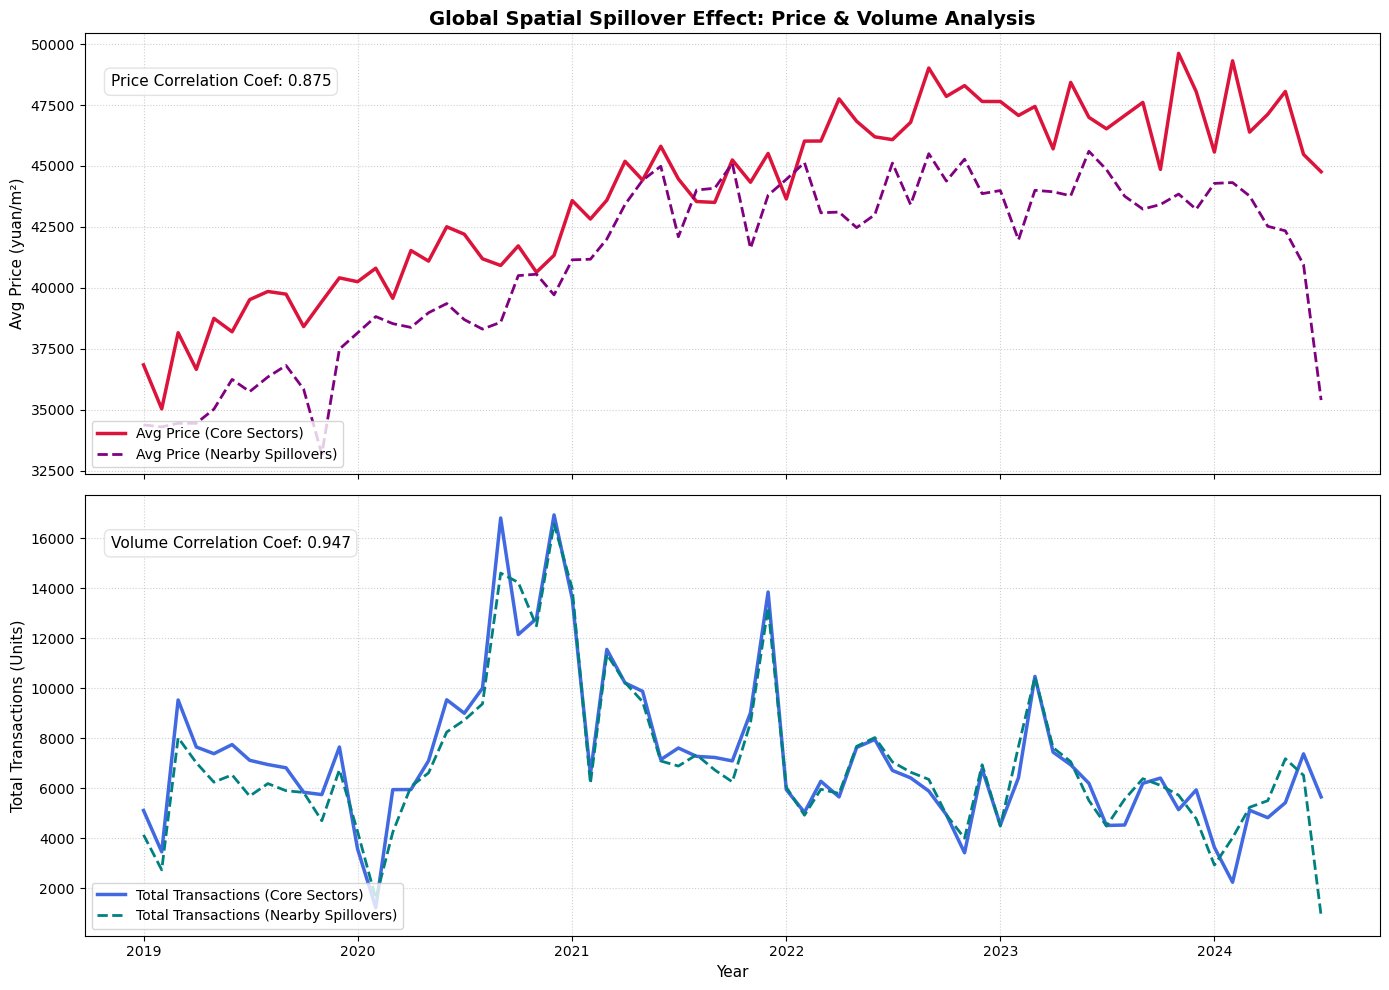

--- Global Analysis Results ---
Price Correlation:  0.8750
Volume Correlation: 0.9474


In [24]:
import pandas as pd
import matplotlib.pyplot as plt

def plot_global_spatial_spillover_with_volume(df):

    df_global = df.copy()
    df_global['month'] = pd.to_datetime(df_global['month'])

    df_trend = df_global.groupby('month').agg({
        'price_new_house_transactions': 'mean',
        'price_new_house_transactions_nearby_sectors': 'mean',
        'num_new_house_transactions': 'sum',
        'num_new_house_transactions_nearby_sectors': 'sum' # Đảm bảo df của bạn có cột này
    }).reset_index().sort_values('month')
    
    price_corr = df_trend['price_new_house_transactions'].corr(df_trend['price_new_house_transactions_nearby_sectors'])
    volume_corr = df_trend['num_new_house_transactions'].corr(df_trend['num_new_house_transactions_nearby_sectors'])
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
    

    ax1.plot(df_trend['month'], df_trend['price_new_house_transactions'], 
             label='Avg Price (Core Sectors)', color='crimson', linewidth=2.5)
    ax1.plot(df_trend['month'], df_trend['price_new_house_transactions_nearby_sectors'], 
             label='Avg Price (Nearby Spillovers)', color='purple', linestyle='--', linewidth=2)
    

    ax1.text(0.02, 0.88, f'Price Correlation Coef: {price_corr:.3f}', 
             transform=ax1.transAxes, fontsize=11, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gainsboro', boxstyle='round,pad=0.4'))
    
    ax1.set_title('Global Spatial Spillover Effect: Price & Volume Analysis', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Avg Price (yuan/m²)', fontsize=11)
    ax1.legend(loc='lower left', fontsize=10)
    ax1.grid(True, linestyle=':', alpha=0.6)
    

    ax2.plot(df_trend['month'], df_trend['num_new_house_transactions'], 
             label='Total Transactions (Core Sectors)', color='royalblue', linewidth=2.5)
    ax2.plot(df_trend['month'], df_trend['num_new_house_transactions_nearby_sectors'], 
             label='Total Transactions (Nearby Spillovers)', color='teal', linestyle='--', linewidth=2)
    

    ax2.text(0.02, 0.88, f'Volume Correlation Coef: {volume_corr:.3f}', 
             transform=ax2.transAxes, fontsize=11, 
             bbox=dict(facecolor='white', alpha=0.8, edgecolor='gainsboro', boxstyle='round,pad=0.4'))
    
    ax2.set_xlabel('Year', fontsize=11)
    ax2.set_ylabel('Total Transactions (Units)', fontsize=11)
    ax2.legend(loc='lower left', fontsize=10)
    ax2.grid(True, linestyle=':', alpha=0.6)
    
  
    plt.tight_layout()
    plt.show()
    
    print(f"--- Global Analysis Results ---")
    print(f"Price Correlation:  {price_corr:.4f}")
    print(f"Volume Correlation: {volume_corr:.4f}")



df_final["price_new_house_transactions_nearby_sectors"] = n_new_trans["price_new_house_transactions_nearby_sectors"]
df_final["num_new_house_transactions_nearby_sectors"] = n_new_trans["num_new_house_transactions_nearby_sectors"]

plot_global_spatial_spillover_with_volume(df_final)

> Market has high degree of interconnectedness. When price of new houses in the center increase, its also triggers pressure increase simultaneously for thóe in nearby sectors in the short period.

> transactions are sensitive with price changes => In 2024, market in crisis or changing policy when price of center decrease slightly but the figure for nearby go dơn rapidly as well as liquidity for nearby seems disappear 

During periods of market stress, buyers tend to prioritize liquidity preservation and shift their demand toward core real estate assets with stronger fundamentals and perceived safety. Nearby or peripheral markets, whose demand is largely driven by spillover effects from central locations, often suffer an immediate decline in liquidity. As a result, these areas may experience significant price corrections as sellers reduce prices to stimulate demand.

### Compare POI with dynamic variables

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_11608\4289951518.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sector_volatility, x='Infra_Quality', y='volatility_index', palette='Set2', width=0.5)


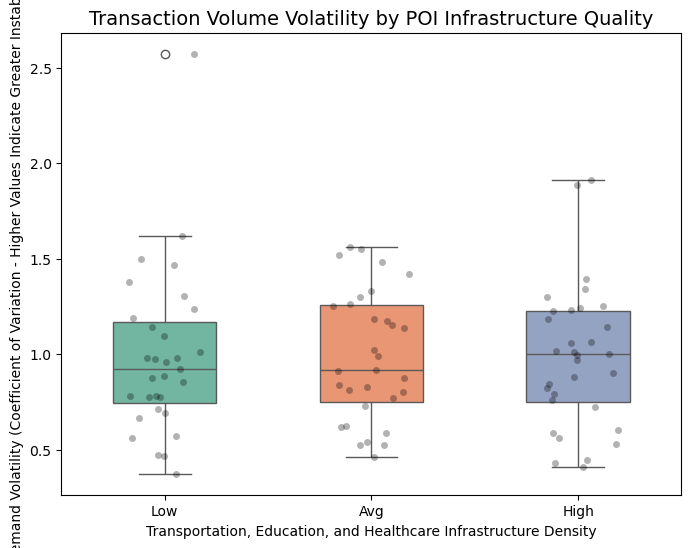

In [25]:

def plot_poi_infrastructure_impact(df):
    df_poi = df.copy()
    
    df_poi['core_infrastructure_density'] = (
        df_poi['transportation_station_dense'].fillna(0) + 
        df_poi['education_dense'].fillna(0) + 
        df_poi['medical_health_dense'].fillna(0)
    )
    
    sector_volatility = df_poi.groupby('sector').agg(
        target_mean=('num_new_house_transactions', 'mean'),
        target_std=('num_new_house_transactions', 'std'),
        infra_density=('core_infrastructure_density', 'first') # Biến tĩnh nên lấy first
    ).reset_index()
    
    sector_volatility['volatility_index'] = sector_volatility['target_std'] / (sector_volatility['target_mean'] + 1e-5)
    
    sector_volatility['Infra_Quality'] = pd.qcut(sector_volatility['infra_density'], q=3, labels=['Low', 'Avg', 'High'])
    
    plt.figure(figsize=(8, 6))
    sns.boxplot(data=sector_volatility, x='Infra_Quality', y='volatility_index', palette='Set2', width=0.5)
    sns.stripplot(data=sector_volatility, x='Infra_Quality', y='volatility_index', color='black', alpha=0.3, jitter=0.2)
    
    plt.title(
        'Transaction Volume Volatility by POI Infrastructure Quality',
        fontsize=14
    )

    plt.xlabel(
        'Transportation, Education, and Healthcare Infrastructure Density'
    )

    plt.ylabel(
        'Demand Volatility (Coefficient of Variation - Higher Values Indicate Greater Instability)'
    )
    plt.show()

df_final["transportation_station_dense"] = poi['transportation_station_dense']
df_final['education_dense'] = poi['education_dense']
df_final['medical_health_dense'] = poi['medical_health_dense']

plot_poi_infrastructure_impact(df_final)

### City indicator

In [26]:
def plot_city_clustering_and_detrend(df, city_indicator_features):
    df_city = df.groupby('sector')[city_indicator_features].last().reset_index()
    
    scaler = StandardScaler()
    scaled_features = scaler.fit_transform(df_city[city_indicator_features].fillna(0))
    
    pca = PCA(n_components=2)
    pca_data = pca.fit_transform(scaled_features)
    df_city['PC1'] = pca_data[:, 0]
    df_city['PC2'] = pca_data[:, 1]
    
    kmeans = KMeans(n_clusters=3, random_state=42)
    df_city['Cluster'] = kmeans.fit_predict(scaled_features)
    df_city['Cluster'] = df_city['Cluster'].map({0: 'Tier 3', 1: 'Tier 2', 2: 'Tier 1'})
    # Relabel đúng theo quy mô giao dịch (PC1)
    tier_map = (
        df_city.groupby('Cluster')['PC1']
        .mean()
        .rank(ascending=False)  # PC1 cao nhất = Tier 1
        .astype(int)
        .to_dict()
    )

    df_city['Tier'] = df_city['Cluster'].map(
        lambda c: f"Tier {tier_map[c]}"
    )
    plt.figure(figsize=(9, 6))
    sns.scatterplot(data=df_city, x='PC1', y='PC2', hue='Cluster', palette='deep', s=100, alpha=0.8, edgecolor='w')
    plt.title('PCA based on sector_indicator_features ', fontsize=14)
    plt.xlabel('PC1')
    plt.ylabel('PC2')
    plt.legend(title='City type')
    plt.show()

In [29]:
# Dùng sector-level features thay vì city macro
sector_indicator_features = [
    'price_new_house_transactions',
    'num_new_house_transactions', 
    'amount_new_house_transactions',
    'period_new_house_sell_through',
    'area_pre_owned_house_transactions',   # từ pre_trans
    'transportation_station_dense',         # từ POI
    'education_dense',
    'medical_health_dense'
]

# Gọi lại hàm với sector features
# plot_city_clustering_and_detrend(df_final, sector_indicator_features)

- Tier 3: low PC1, high PC2 => small sector, good infrasstructure => stable, less liquid
 
- Tier 2: PC1 ~ 0, PC2 spread => Most of sectors

- Tier 1: high PC1, low PC2 => Mega sectors, huge volume, unoticeable infrasstructure

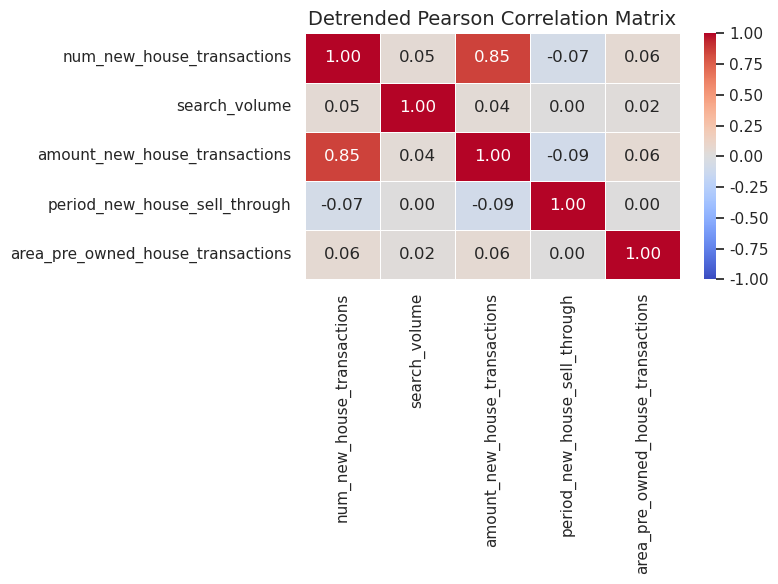

In [ ]:

def plot_corr(df):
    monthly_dynamic_vars = [
        'num_new_house_transactions',     
        'search_volume', 
        'amount_new_house_transactions',            
        'period_new_house_sell_through',   
        'area_pre_owned_house_transactions'
    ]
    
    
    df_diff = df.sort_values(['sector', 'month']).groupby('sector')[monthly_dynamic_vars].diff().dropna()
    
    corr_matrix = df_diff.corr()
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", vmin=-1, vmax=1, linewidths=0.5)
    plt.title('Detrended Pearson Correlation Matrix', fontsize=14)
    plt.tight_layout()
    plt.show()
df_final['area_pre_owned_house_transactions'] = pre_trans['area_pre_owned_house_transactions']
plot_corr(df_final)

# Summary : 

## Target and Distribution

- Right-skewed, long-tailed distributions: All numeric features are right-skewed with heavy tails. Mean >> median. Log1p transform stabilises variance significantly and exposes four cleaner market regimes.

- Four structural regimes (2019–2024): Pre-COVID baseline (2019) → COVID shock bottom (early 2020) → Strong bull run (late 2020–2021) → Post-"3 Red Lines" policy decline (2022–2024). Regime labels are strong features.

- Seasonal pattern (late-year surge): Transaction volume and value rise noticeably in Q4 each year. STL decomposition confirms cyclical seasonality with a 12-month period, plus a residual trend component.

## Spatial and Sector Heterogeneity

- Sector 55 dominates volume & value: A single sector accounts for the majority of transactions. The market is highly concentrated — a small number of sectors drive the bulk of volume.

- Three sector segments identified: 

    + Stable blue-chips high value, low CV, predictable.

    + High-risk small high CV > 1, noisy signal.

    + High-reward volatile large but unstable, short-term plays.

- Strong spatial spillover (price & volume): Core sector prices and nearby sector prices move together (high correlation). In 2024, nearby-sector liquidity collapsed faster than core, confirming a flight-to-quality dynamic during stress.

## Exogeneous Signals

- Search volume leads transactions by 0–1 month: CCF analysis shows demand converts quickly. But despite high search intent, many high-volume sectors carry 12–20 months of unsold inventory — structural over-supply bottleneck.

- Infrastructure density reduces demand volatility: Sectors with high transport, education, and healthcare POI density show lower coefficient-of-variation in transactions. Infrastructure is a stabilising moderator variable.

- Liquidity and volatility are inversely correlated: Higher transaction volume → lower rolling volatility. Volatility clusters (ARCH-like behaviour) and spikes asymmetrically upward — shocks are larger than recoveries.

- Pre-owned market area correlates with new-house volume: Detrended correlation matrix shows pre-owned transaction area and new-house transactions move together — substitution and complementary demand dynamics both present.

# Model Design: 

## Modeling strategy

- Using model follow direct prediction

- Tree-based baseline: LightGBM / XGBoost handles non-linearity and skewness well; good starting point before neural approaches

- Volatility-aware loss: Use asymmetric or quantile loss (e.g. Huber or pinball) given the upward-spike pattern in residuals

- Regime-conditional forecast: Consider a mixture model or regime-switching layer — a single model will struggle across the 4 structural phases

## Preprocessing and feature engineer 
 
- Outliers : Those huge amount transactions are real => makes distributions skew to right => we use log1p for target

- Encode the four regimes explicitly. The 2020 COVID shock and the 2022 "3 Red Lines" policy break are structural, not just noise. A model that doesn't know which regime it's in will learn a muddled average. You can use a simple date-based categorical variable or interaction terms.

- Time-series CV only

- Out-of-regime test set